In [1]:
# We need it in all codes
import numpy as np 
import math

# We again measure computational time and try to use sparse matrices
import scipy.sparse
from scipy.sparse import csr_matrix
from timeit import default_timer as timer

# We manipulate again a picture
from PIL import Image
import matplotlib.pyplot as plt


# See functions here
# https://numpy.org/doc/stable/reference/generated/numpy.exp.html
# https://numpy.org/doc/stable/reference/routines.array-manipulation.html
#

# basic vector and matrix operations
# general principle: we do not have to write functions for everything
# moreover, built-in vectorized operations are rather fast


# SVD DECOMPOSITION

In [2]:
# Let us begin with an easy example.
A = np.array([[2,1,1,0],[2,1,0,1]])

print(f"A has shape : {A.shape}")
#Full matrix decomposition A = U ∑ V^T, A shape = (n,k)
#This function returns U and V (if compute_uv =TRUE) and the singular values in an array of size r = min(n,k)
#Hermitian false since we know A is not symmetric.
U, sigma, vt = np.linalg.svd(A, full_matrices=True, compute_uv=True, hermitian=False)

print( f" The orthogonal matrix U: {U}")

print(f"The singular values :{sigma}")
print("The orthogonal matrix V:")
print(vt)

A has shape : (2, 4)
 The orthogonal matrix U: [[-0.70710678 -0.70710678]
 [-0.70710678  0.70710678]]
The singular values :[3.31662479 1.        ]
The orthogonal matrix V:
[[-8.52802865e-01 -4.26401433e-01 -2.13200716e-01 -2.13200716e-01]
 [-4.41123944e-17  8.42395647e-17 -7.07106781e-01  7.07106781e-01]
 [-5.10060301e-01  5.56152381e-01  4.63968220e-01  4.63968220e-01]
 [ 1.12097112e-01 -7.13355695e-01  4.89161471e-01  4.89161471e-01]]


In [3]:
# Go on with this example.
A = np.array([[2,1,1,0],[2,1,0,1]])
# Get the reduced form.
U, Sigma, V = np.linalg.svd(A, full_matrices=False, compute_uv=True, hermitian=False)
# Scale it to have a more visible form.
print(math.sqrt(2)*U)
print(Sigma)
print(V/math.sqrt(2))

[[-1. -1.]
 [-1.  1.]]
[3.31662479 1.        ]
[[-6.03022689e-01 -3.01511345e-01 -1.50755672e-01 -1.50755672e-01]
 [-3.11921732e-17  5.95663675e-17 -5.00000000e-01  5.00000000e-01]]


In [4]:
# Take again a tridiagonal symmetric matrix and construct its 
# eigenvalue decomposition.
from scipy.sparse import dia_matrix
from scipy.sparse import csc_matrix
from scipy.sparse.linalg import spsolve
n = 100
ex = np.ones(n)
# This will be a tridiagonal matrix
# We first create an array consisting of the diagonals.
data = np.array([ex, -4 * ex, ex])
# We also say, in which diagonals should the rows be inserted
# (related to the main diagonal).
offsets = np.array([-1, 0, 1])
# Then the matrix is collected.
trd = dia_matrix((data, offsets), shape=(n, n)).toarray()
# Be careful; this should be converted to a sparse matrix.
S_100 = csr_matrix(trd)

# Measure computational time. 
# Observe that for symmetric matrices (if it is declared) it works faster 
start = timer()
np.linalg.svd(trd, full_matrices=True, compute_uv=True, hermitian=True)
end = timer()
print("Time it takes to perform SVD on a symmetric matrix:")
print(end - start)

# For the same matrix, but simmetricity was not declared.
start = timer()
np.linalg.svd(trd, full_matrices=True, compute_uv=True, hermitian=False)
end = timer()
print("Time it takes to perform SVD on a symmetric matrix but not taking advantage of this property:")

print(end - start)

Time it takes to perform SVD on a symmetric matrix:
0.0005536670068977401
Time it takes to perform SVD on a symmetric matrix but not taking advantage of this property:
0.0006787910097045824


In [10]:


#DOES THIS WORK FOR SPARSE MATRICES TOO?

#Recall dia_matrix returns a sparse matrix that then we turn into a  a dense matrix,
# using .toarray()
#  and csr_matrix has sparse structure.
# for sparse matrices we can use from scipy.sparse.linalg import svds
start = timer()
np.linalg.svd(S_100, full_matrices=True, compute_uv=True, hermitian=True)
end = timer()
print(end - start)

# No. That's bad.

LinAlgError: 0-dimensional array given. Array must be at least two-dimensional

In [13]:
# What is the computational time for a random matrix of the same size?
A = np.random.rand(100,100)
start = timer()
np.linalg.svd(A, full_matrices=True, compute_uv=True, hermitian=False)
end = timer()
print(end - start)
# Hmm, no real difference.

0.002138666997780092


In [ ]:
A = np.array([[2,1,1,0],[2,1,0,1]])
U, sigma, vt = np.linalg.svd(A, full_matrices=True, compute_uv=True, hermitian=False)

#Lets try to recreate A using the fact that is the sum of rank 1 matrices.
#We need to use the outer product(u,v) = matrix u v^T
#This is rank 1 because every column is a multiple of u (multiples given by v actually).
A_reconstructed = np.zeros (np.shape(A))
for i in np.arange(0, np.size(sigma)):
    A_reconstructed = A_reconstructed + sigma[i] * np.outer ( U[:,i], vt [i,:] ) 
print(A_reconstructed)

[[ 2.00000000e+00  1.00000000e+00  1.00000000e+00  1.11022302e-16]
 [ 2.00000000e+00  1.00000000e+00 -2.22044605e-16  1.00000000e+00]]


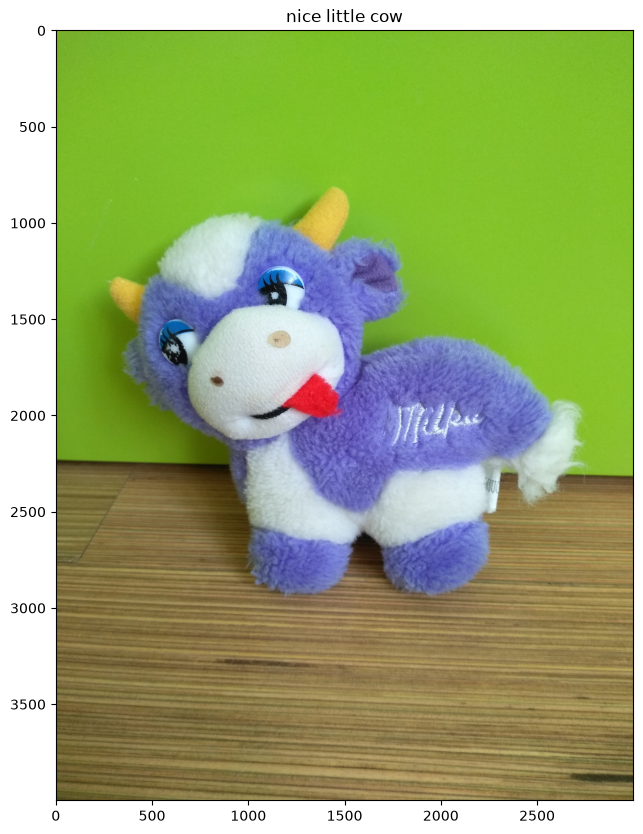

In [16]:
# OK, let us try to compress an image.
# First get it first.
image = np.array(Image.open("toy_cow.jpg")) 
# Also, show this
fig = plt.figure(figsize=(15, 10))
imgplot = plt.imshow(image)
plt.title("nice little cow")
plt.show()

In [17]:
# Decompose it into the three color "channels"

print(image.shape)

# First "layer": red component, second layer: green component
# third "layer": blue component 
# All of them: integers in [0,255].
# Let us get them really separately: 

red_comp = image[:,:,0]
green_comp = image[:,:,1]
blue_comp = image[:,:,2]

red_comp = red_comp.astype('float64')
green_comp = green_comp.astype('float64')
blue_comp = blue_comp.astype('float64')

(4000, 3000, 3)


In [18]:
U_red, Sigma_red, V_red = np.linalg.svd(red_comp, full_matrices=True, compute_uv=True, hermitian=False)
U_green, Sigma_green, V_green = np.linalg.svd(green_comp, full_matrices=True, compute_uv=True, hermitian=False)
U_blue, Sigma_blue, V_blue = np.linalg.svd(blue_comp, full_matrices=True, compute_uv=True, hermitian=False)

In [19]:
k = 50

# Take the first k columns of U.
U_red_k = U_red[:, :k]
# Take the first k rows of V.
V_red_k = V_red[:k, :]

# Perform the same for the other components, too.
U_green_k = U_green[:, :k]
V_green_k = V_green[:k, :]

U_blue_k = U_blue[:, :k]
V_blue_k = V_blue[:k, :]

# Take the first k singular values.
Sigma_red_k = Sigma_red[:k]
Sigma_green_k = Sigma_green[:k]
Sigma_blue_k = Sigma_blue[:k]

# Be careful this is a vector; we have 
# still to reconstruct diagonal matrices from these.

# Check shapes:
print(U_red_k.shape)
print(V_red_k.shape)
print(Sigma_red_k.shape)


(4000, 50)
(50, 3000)
(50,)


In [ ]:
# Reconstruct diagonal matrices from vectors. Remember svd returns singular values as a 1d array.
Sigma_red_k = np.diag(Sigma_red_k)
Sigma_green_k = np.diag(Sigma_green_k)
Sigma_blue_k = np.diag(Sigma_blue_k)

In [21]:
# Reconstruct the full matrices from the components.
red_k = U_red_k @ Sigma_red_k @ V_red_k
green_k = U_green_k @ Sigma_green_k @ V_green_k
blue_k = U_blue_k @ Sigma_blue_k @ V_blue_k
print(red_k.shape)
print(green_k.shape)
print(blue_k.shape)

(4000, 3000)
(4000, 3000)
(4000, 3000)


In [22]:

reduced_cow = np.zeros((4000, 3000, 3))

reduced_cow[:, :, 0] = red_k
reduced_cow[:, :, 1] = green_k
reduced_cow[:, :, 2] = blue_k

# Technical detail for the figure.
reduced_cow = reduced_cow.astype(int)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-18..264].


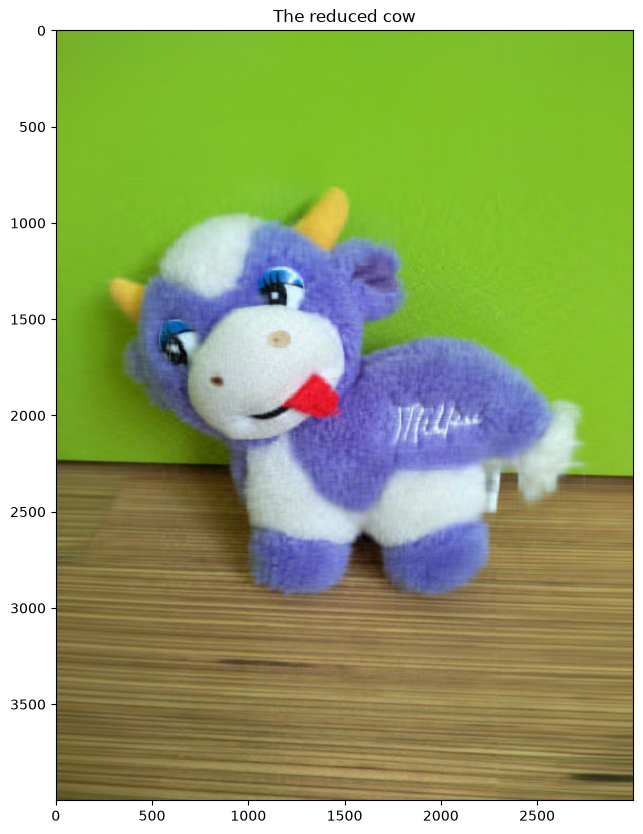

In [23]:
fig = plt.figure(figsize=(15, 10))
plt.imshow(reduced_cow)
plt.title('The reduced cow')
plt.show()